Travese a graph to assign flow levels

use this

https://navis.readthedocs.io/en/latest/source/generated/navis.models.network_models.TraversalModel.html#navis.models.network_models.TraversalModel

https://navis-org.github.io/navis/reference/navis/models/#navis.models.BayesianTraversalModel

things to try

1. remove edge going from higher levels to lower levels, then rerun traversal to check the level assignment to check if it's indeed feedback


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
"""
This cell does the initial project setup.
If you start a new script or notebook, make sure to copy & paste this part.

A script with this code uses the location of the `.env` file as the anchor for
the whole project (= PROJECT_ROOT). Afterwards, code inside the `src` directory
are available for import.
"""
from pathlib import Path
import sys
from dotenv import load_dotenv, find_dotenv
load_dotenv()
PROJECT_ROOT = Path(find_dotenv()).parent
sys.path.append(str(PROJECT_ROOT.joinpath('src')))
print(f"Project root directory: {PROJECT_ROOT}")

In [ ]:
from utils import olc_client
c = olc_client.connect(verbose=True)

In [6]:
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt

import cmap

import pandas as pd
import numpy as np
import pickle as pkl
import re
import os, datetime
# from openpyxl.styles import Font

In [5]:
import neuprint
# print(neuprint.__version__)
from neuprint import fetch_neurons, fetch_synapses, fetch_synapse_connections
from neuprint import fetch_adjacencies, merge_neuron_properties, connection_table_to_matrix
from neuprint import NeuronCriteria as NC, SynapseCriteria as SC
# from neuprint.queries import fetch_all_rois, fetch_roi_hierarchy

import navis
import navis.interfaces.neuprint as neu

# load data

In [ ]:
from utils.config import DATA_DIR, FIG_DIR

result_dir = FIG_DIR / 'network'
result_dir.mkdir(parents=True, exist_ok=True)

neuron_info = pd.read_pickle(DATA_DIR / 'neuron_info_ol.pkl')
edgelist = pd.read_pickle(DATA_DIR / 'edgelist_ol.pkl')

In [8]:
edgelist.shape

(6482126, 4)

In [ ]:
# # filter edgelist, keeping only nodes that have a type starting with 'OL' in neuron_info
# onn = neuron_info[neuron_info.main_groups.str.startswith('OL')]

# el_onn = edgelist[edgelist.bodyId_pre.isin(onn.bodyId) & edgelist.bodyId_post.isin(onn.bodyId)]
# el_onn.shape

In [9]:
# cell graph
# el0 = neuprint.merge_neuron_properties(onn, el_onn, ['type','instance'])
el0 = neuprint.merge_neuron_properties(neuron_info, edgelist, ['type','instance'])
print(el0.shape)

# type graph
# el0 = el0.groupby(['instance_pre', 'instance_post']).agg(
#     weight = ("weight", "sum")
# ).reset_index()

(6482126, 8)


Threshold edges >= , and normalize by incoming connections

In [ ]:
el = el0[el0['weight'] >= 5]
print(el.shape)

# normalize weight by the bodyId_post upstream value in neuron_info
el = el.merge(neuron_info[['bodyId', 'upstream']], left_on='bodyId_post', right_on='bodyId', how='left')
el['weight_norm'] = el['weight'] / el['upstream']

(1553924, 8)


### add nt to have neg wt

In [ ]:
# # add nt info, change wt to neg for gaba/glutamate
# el = el.merge(neuron_info[['bodyId', 'consensusNt']], left_on='bodyId_pre', right_on='bodyId', how='left')
# # change weight_norm to negative if consensus is gaba or glutamate
# el.loc[el.consensusNt.isin(['gaba', 'glutamate']), 'weight_norm'] = -el.loc[el.consensusNt.isin(['gaba', 'glutamate']), 'weight_norm']

# Bayesian Model

At each time step, check all incoming connections with a pre-defined activation function, compute the probability that at least one of these connections will be active, which adds to the cumulative probability of the node being active.

In [ ]:
# download modified navis
# pip install git+https://github.com/artxz/navis@master

In [10]:
from navis.models import BayesianTraversalModel
from navis.models import linear_activation_with_neg

In [29]:
%%time

edges = el[['bodyId_pre', 'bodyId_post', 'weight_norm']]
edges.columns = ['source', 'target', 'weight']
seeds = neuron_info[neuron_info['type'].str.contains(r'(^L[1-3]{1})|(^R[78]{1})|(HBeyelet)')] ['bodyId'].values

def my_act(x):
    return linear_activation_with_neg(x, neg_w=-1, pos_w= 0.3)

model = BayesianTraversalModel(edges, seeds, max_steps=10, traversal_func= my_act)

# Run model
res = model.run()
summ = model.summary

<timed exec>:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.


0it [00:00, ?it/s]

CPU times: total: 34min 9s
Wall time: 34min 30s


In [13]:
# save the results
# pkl.dump({'model': model}, open(Path(result_dir, 'bayesian_traversal_model_thr4.pkl'), 'wb'))

# load the results
# res = pkl.load(open(Path(result_dir, 'bayesian_traversal_model_thr4_res.pkl'), 'rb'))
# summ = pkl.load(open(Path(result_dir, 'bayesian_traversal_model_thr4_summary.pkl'), 'rb'))

# save df 
# res.to_pickle(Path(result_dir, 'bayesian_traversal_model_actf_3_res.pkl'))
# summ.to_pickle(Path(result_dir, 'bayesian_traversal_model_actf_3_summary.pkl'))

# load df
# res = pd.read_pickle(Path(result_dir, 'bayesian_traversal_model_actf_3_res.pkl'))
# summ = pd.read_pickle(Path(result_dir, 'bayesian_traversal_model_actf_3_summary.pkl'))

## run all neurons

In [14]:
neuron_info[neuron_info['type'].str.contains(r'(^L[1-3]{1})|(^R[78]{1})|(HBeyelet)')] ['instance'].value_counts()

C:\Users\zhaoa\AppData\Local\Temp\ipykernel_17252\232758723.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  neuron_info[neuron_info['type'].str.contains(r'(^L[1-3]{1})|(^R[78]{1})|(HBeyelet)')] ['instance'].value_counts()


instance
L2_R              893
L1_R              892
L3_R              892
R7p_R             297
R8p_R             294
R7y_R             246
R8y_R             244
R8_unclear_R      123
R7_unclear_R      100
R7R8_unclear_R     86
R7d_R              42
R8d_R              41
HBeyelet_R          3
Name: count, dtype: int64

In [14]:
%%time

edges = el[['bodyId_pre', 'bodyId_post', 'weight_norm']]
edges.columns = ['source', 'target', 'weight']
# seeds = neuron_info[neuron_info['type'].str.contains(r'(^L[1-5]{1})|(^R[78]{1})')]['bodyId'].values
seeds = neuron_info[neuron_info['type'].str.contains(r'(^L[1-3]{1})|(^R[78]{1})|(HBeyelet)')] ['bodyId'].values


for i in range(1, 11):
    def my_act(x):
        # return linear_activation_p(x, min_w=0, max_w= i/10)
        return linear_activation_with_neg(x, neg_w=-1, pos_w= i/10)

    model = BayesianTraversalModel(edges, seeds, max_steps=10, traversal_func= my_act)

    # Run model
    res = model.run()
    summ = model.summary

    # save df 
    res.to_pickle(Path(result_dir, 'scan_all', f'btModel_ethr5_maxW_{i}.pkl'))
    summ.to_pickle(Path(result_dir, 'scan_all',  f'btModel_ethr5_summary_maxW_{i}.pkl'))
    # res.to_pickle(Path(result_dir, 'scan_all', f'btModel_ethr5_nt_maxW_{i}.pkl'))
    # summ.to_pickle(Path(result_dir, 'scan_all',  f'btModel_ethr5_nt_summary_maxW_{i}.pkl'))

<timed exec>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

CPU times: user 6h 8min 19s, sys: 1.01 s, total: 6h 8min 20s
Wall time: 6h 8min 21s


# MBR Model

In [11]:
from navis.models import MBRTraversalModel
from navis.models import linear_activation_p, linear_activation_with_neg

In [27]:
# %%time

# edges = el[['bodyId_pre', 'bodyId_post', 'weight_norm']]
# edges.columns = ['source', 'target', 'weight']

# seeds = neuron_info[neuron_info['type'].str.contains(r'(^L[1-5]{1})|(^R[78]{1})')]['bodyId'].values


# def my_act(x):
#     return linear_activation_p(x, min_w=0, max_w=1)

# thr = 0.1
# N_steps = 10
# model = MBRTraversalModel(edges, seeds, max_steps=N_steps, threshold= thr, traversal_func= my_act)

CPU times: total: 93.8 ms
Wall time: 91.5 ms


<timed exec>:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.


In [ ]:
# # Run model, log run time
# res = model.run()

## run all neurons

In [ ]:
%%time

edges = el[['bodyId_pre', 'bodyId_post', 'weight_norm']]
edges.columns = ['source', 'target', 'weight']
# seeds = neuron_info[neuron_info['type'].str.contains(r'(^L[1-5]{1})|(^R[78]{1})')]['bodyId'].values
seeds = neuron_info[neuron_info['type'].str.contains(r'(^L[1-3]{1})|(^R[78]{1})|(HBeyelet)')] ['bodyId'].values


N_steps = 10
def my_act(x):
        # return linear_activation_p(x, min_w=0, max_w=1)
        return linear_activation_with_neg(x, min_w=-1, max_w=1)
for i in range(1, 11):
    thr = i / 10
    model = MBRTraversalModel(edges, seeds, max_steps=N_steps, threshold= thr, traversal_func= my_act)

    # Run model
    res = model.run()
    summ = model.summary

    # save df 
    res.to_pickle(Path(result_dir, 'scan_all', f'mbrModel_ethr5_cumprop_{i}.pkl'))
    summ.to_pickle(Path(result_dir, 'scan_all', f'mbrModel_ethr5_cumprop_{i}_summary.pkl'))

In [29]:
# # group by type
# df = pd.merge(neuron_info, model.summary['layer_median'].reset_index(), 
#          left_on='bodyId', right_on='node', how='left')
# df = df.groupby('type').agg({'layer_median':'median'}).reset_index()

# Test the model

In [22]:
el = np.array([[0,1,1],
               [1,2,0.5],
               [0,2,0.5],
               [2,3,0.4]])
edges0 = pd.DataFrame(el, columns=['source', 'target', 'weight'])
# specify data types
edges0 = edges0.astype({'source': 'int64', 'target': 'int64', 'weight': 'float64'})
print(edges0)
seeds = [0,1]

   source  target  weight
0       0       1     1.0
1       1       2     0.5
2       0       2     0.5
3       2       3     0.4


In [17]:
# edges0 = edges.copy()
# target0 = edges0['target']
# source0 = edges0['source']
# weights0 = edges0['weight']
max_steps = 4
seeds0 = seeds.copy()

from navis.models import random_linear_activation_function, linear_activation_p

def linear_activation_with_neg_1(
    w: np.ndarray,
    neg_w: float = -1,
    pos_w: float = 1,
) -> np.ndarray:
    # w = w / np.sum(np.abs(w))
    # separate positive and negative weights
    neg_idx = w < 0
    pos_idx = w >= 0
    w[neg_idx] = np.clip(-(w[neg_idx] - 0) / (neg_w - 0), -1., 0.)
    w[pos_idx] = np.clip((w[pos_idx] - 0) / (pos_w - 0), 0., 1.)

    return w

In [23]:
edges = edges0.values
id_type = edges0['source'].dtype
# Transform weights to traversal probabilities
edges[:, 2] = linear_activation_with_neg_1(edges[:, 2])



In [24]:

# Change node IDs into indices in [0, len(nodes))
ids, edges_idx = np.unique(edges[:, :2], return_inverse=True)
ids = ids.astype(id_type)
edges_idx = edges_idx.reshape((edges.shape[0], 2))
print(edges_idx.shape)
edges_idx = np.concatenate(
    (edges_idx, np.expand_dims(edges[:, 2], axis=1)),
    axis=1)



(4, 2)


In [25]:
# ids[:3]
edges_idx

array([[0. , 1. , 1. ],
       [1. , 2. , 0.5],
       [0. , 2. , 0.5],
       [2. , 3. , 0.4]])

In [26]:

cmfs = np.zeros((len(ids), max_steps), dtype=np.float64)
seed_idx = np.searchsorted(ids, seeds0)
cmfs[seed_idx, :] = 1.
changed = set(edges_idx[np.isin(edges_idx[:, 0], seed_idx), 1].astype(id_type))

In [27]:
changed

{1, 2}

In [33]:
# first in set changed
idx = 2

cmf = cmfs[idx, :]
inbound = edges_idx[edges_idx[:, 1] == idx, :]
pre = inbound[:, 0].astype(np.int64)

In [34]:
# edges_idx
print(inbound)
print(pre)

[[1.  2.  0.5]
 [0.  2.  0.5]]
[1 0]


In [35]:
cmfs[pre, :] 

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [36]:

# Traversal probability for each inbound edge at each time.
posteriors = cmfs[pre, :] * np.expand_dims(inbound[:, 2], axis=1)
posteriors

array([[0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5]])

In [32]:
# np.array([[1,2],[3,4]]) * np.array([[1],[2]])
# np.array([[1,2],[3,4]]) * np.array([[1,2]])

In [37]:
new_pmf = 1 - np.prod(1 - posteriors, axis=0)
print(new_pmf)
new_cmf = cmf.copy()

[0.75 0.75 0.75 0.75]


In [38]:
print(cmf[1:])
print( np.cumprod(1 - new_pmf[:-1]))
print([1,2,3][:-1])

[0. 0. 0.]
[0.25     0.0625   0.015625]
[1, 2]


In [39]:
# np.maximum(cmf[1:], 1 - np.cumprod(1 - new_pmf[:-1]))
new_cmf[1:] = np.maximum(cmf[1:], 1 - np.cumprod(1 - new_pmf[:-1]))
np.clip(new_cmf, 0., 1., out=new_cmf)
new_cmf

array([0.      , 0.75    , 0.9375  , 0.984375])

In [40]:
cmfs[idx, :] = new_cmf
cmfs

array([[1.      , 1.      , 1.      , 1.      ],
       [1.      , 1.      , 1.      , 1.      ],
       [0.      , 0.75    , 0.9375  , 0.984375],
       [0.      , 0.      , 0.      , 0.      ]])

In [ ]:
next_changed = []

for idx in changed:
    cmf = cmfs[idx, :] # current time-cumulative probability
    inbound = edges_idx[edges_idx[:, 1] == idx, :] # all incoming edges
    pre = inbound[:, 0].astype(np.int64) # incoming nodes

    # Traversal probability for each inbound edge at each time.
    posteriors = cmfs[pre, :] * np.expand_dims(inbound[:, 2], axis=1)
    # At each time, compute the probability that at least one inbound edge
    # is traversed.
    new_pmf = 1 - np.prod(1 - posteriors, axis=0)
    new_cmf = cmf.copy()
    # Offset the time-cumulative probability by 1 to account for traversal iteration.
    # Use maximum of previous CMF as it is monotonic and to include fixed seed traversal.
    new_cmf[1:] = np.maximum(cmf[1:], 1 - np.cumprod(1 - new_pmf[:-1]))
    np.clip(new_cmf, 0., 1., out=new_cmf)

    if np.allclose(cmf, new_cmf):
        continue

    cmfs[idx, :] = new_cmf

    # Notify downstream nodes that they have changed next iteration.
    post_idx = edges_idx[edges_idx[:, 0] == idx, 1].astype(id_type)
    next_changed.extend(list(post_idx))

In [ ]:
next_changed

[1, 3]

# Test with an example graph

In [6]:
A = np.array([[0,1],[1,0]])
0.3 ** A

array([[1. , 0.3],
       [0.3, 1. ]])

In [43]:
# el = np.array([[0,1,0],
#                [0,2,0.5],
#                [1,2, 0.5],
#                [1,3,0.5]])
# seeds = [0]

el = np.array([
   # [0,1,0],
   [0,2,.2],
   [0,3,.2],
   [0,4,.3],
   [1,4,.2],
   [2,3,0.2],
   [4,3,0.1]])
seeds = [0, 1]

edges = pd.DataFrame(el, columns=['source', 'target', 'weight'])
# specify data types
edges = edges.astype({'source': 'int64', 'target': 'int64', 'weight': 'float64'})
edges

,source,target,weight
0,0,2,0.2
1,0,3,0.2
2,0,4,0.3
3,1,4,0.2
4,2,3,0.2
5,4,3,0.1


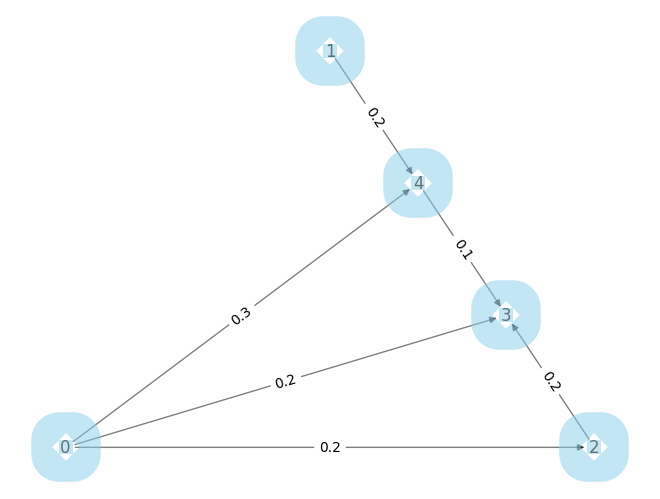

In [44]:
# make graph
import networkx as nx
G = nx.from_pandas_edgelist(edges, source='source', target='target', edge_attr='weight', create_using=nx.DiGraph)
# draw graph
# pos = nx.spring_layout(G)
# pos = nx.circular_layout(G)
pos = nx.planar_layout(G)
nx.draw(G, pos, with_labels=True, node_size=100, node_color="skyblue", node_shape="s", alpha=0.5, linewidths=40)
# draw edge labels
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()

In [45]:
def linear_activation_1(
    w: np.ndarray,
    min_w: float = 0,
    max_w: float = 0.4,
) -> np.ndarray:
    return np.clip((w - min_w) / (max_w - min_w), 0., 1.)

In [29]:
def linear_activation_with_neg_1(
    w: np.ndarray,
    neg_w: float = -1,
    pos_w: float = 1,
) -> np.ndarray:
    # w = w / np.sum(np.abs(w))
    # separate positive and negative weights
    neg_idx = w < 0
    pos_idx = w >= 0
    w[neg_idx] = np.clip(-(w[neg_idx] - 0) / (neg_w - 0), -1., 0.)
    w[pos_idx] = np.clip((w[pos_idx] - 0) / (pos_w - 0), 0., 1.)

    return w

In [30]:
linear_activation_with_neg_1(np.array([-2, -0.5, 0.1, 0.2, 0.3, 1, 2]))

array([-1. , -0.5,  0.1,  0.2,  0.3,  1. ,  1. ])

In [46]:
from navis.models import BayesianTraversalModel
model = BayesianTraversalModel(edges, seeds, max_steps=5, traversal_func=linear_activation_1)
# model = BayesianTraversalModel(edges, seeds, max_steps=5, traversal_func=linear_activation_with_neg_1)
# model = BayesianTraversalModel(edges, seeds, max_steps=5)
# Run model
res = model.run()
# Get a summary
model.summary.tail()   

0it [00:00, ?it/s]

,layer_min,layer_max,layer_mean,layer_median
node,,,,
0,1,1,1.000000,1.0
1,1,1,1.000000,1.0
2,2,6,2.625000,2.0
3,2,6,2.651858,2.0
4,2,6,2.141602,2.0


In [47]:
model.results['cmf']

0                            [1.0, 1.0, 1.0, 1.0, 1.0]
1                            [1.0, 1.0, 1.0, 1.0, 1.0]
2                      [0.0, 0.5, 0.75, 0.875, 0.9375]
3    [0.0, 0.5, 0.853515625, 0.9654889106750488, 0....
4    [0.0, 0.875, 0.984375, 0.998046875, 0.99975585...
Name: cmf, dtype: object

In [ ]:
1-np.cumprod([0.5,0.5,0.5,0.5])

array([0.5   , 0.75  , 0.875 , 0.9375])